In [1]:
import yfinance as yf
from datetime import datetime, timedelta

# 1. Define the ticker for Intuit
ticker_symbol = "INTU"

# 2. Calculate the date range (1 year ago from today)
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

print(f"Fetching data for {ticker_symbol} from {start_date.date()} to {end_date.date()}...")

# 3. Download the data
# 'Adj Close' is best for accurate historical averages
data = yf.download(ticker_symbol, start=start_date, end=end_date)

if not data.empty:
    # 4. Calculate the average of the Closing prices
    # We add .item() to convert the result into a simple number
    average_price = data['Close'].mean().item()
    
    print("-" * 30)
    print(f"Average Closing Price (Last Year): ${average_price:.2f}")
    print("-" * 30)

Fetching data for INTU from 2025-03-16 to 2026-03-16...


[*********************100%***********************]  1 of 1 completed

------------------------------
Average Closing Price (Last Year): $641.36
------------------------------


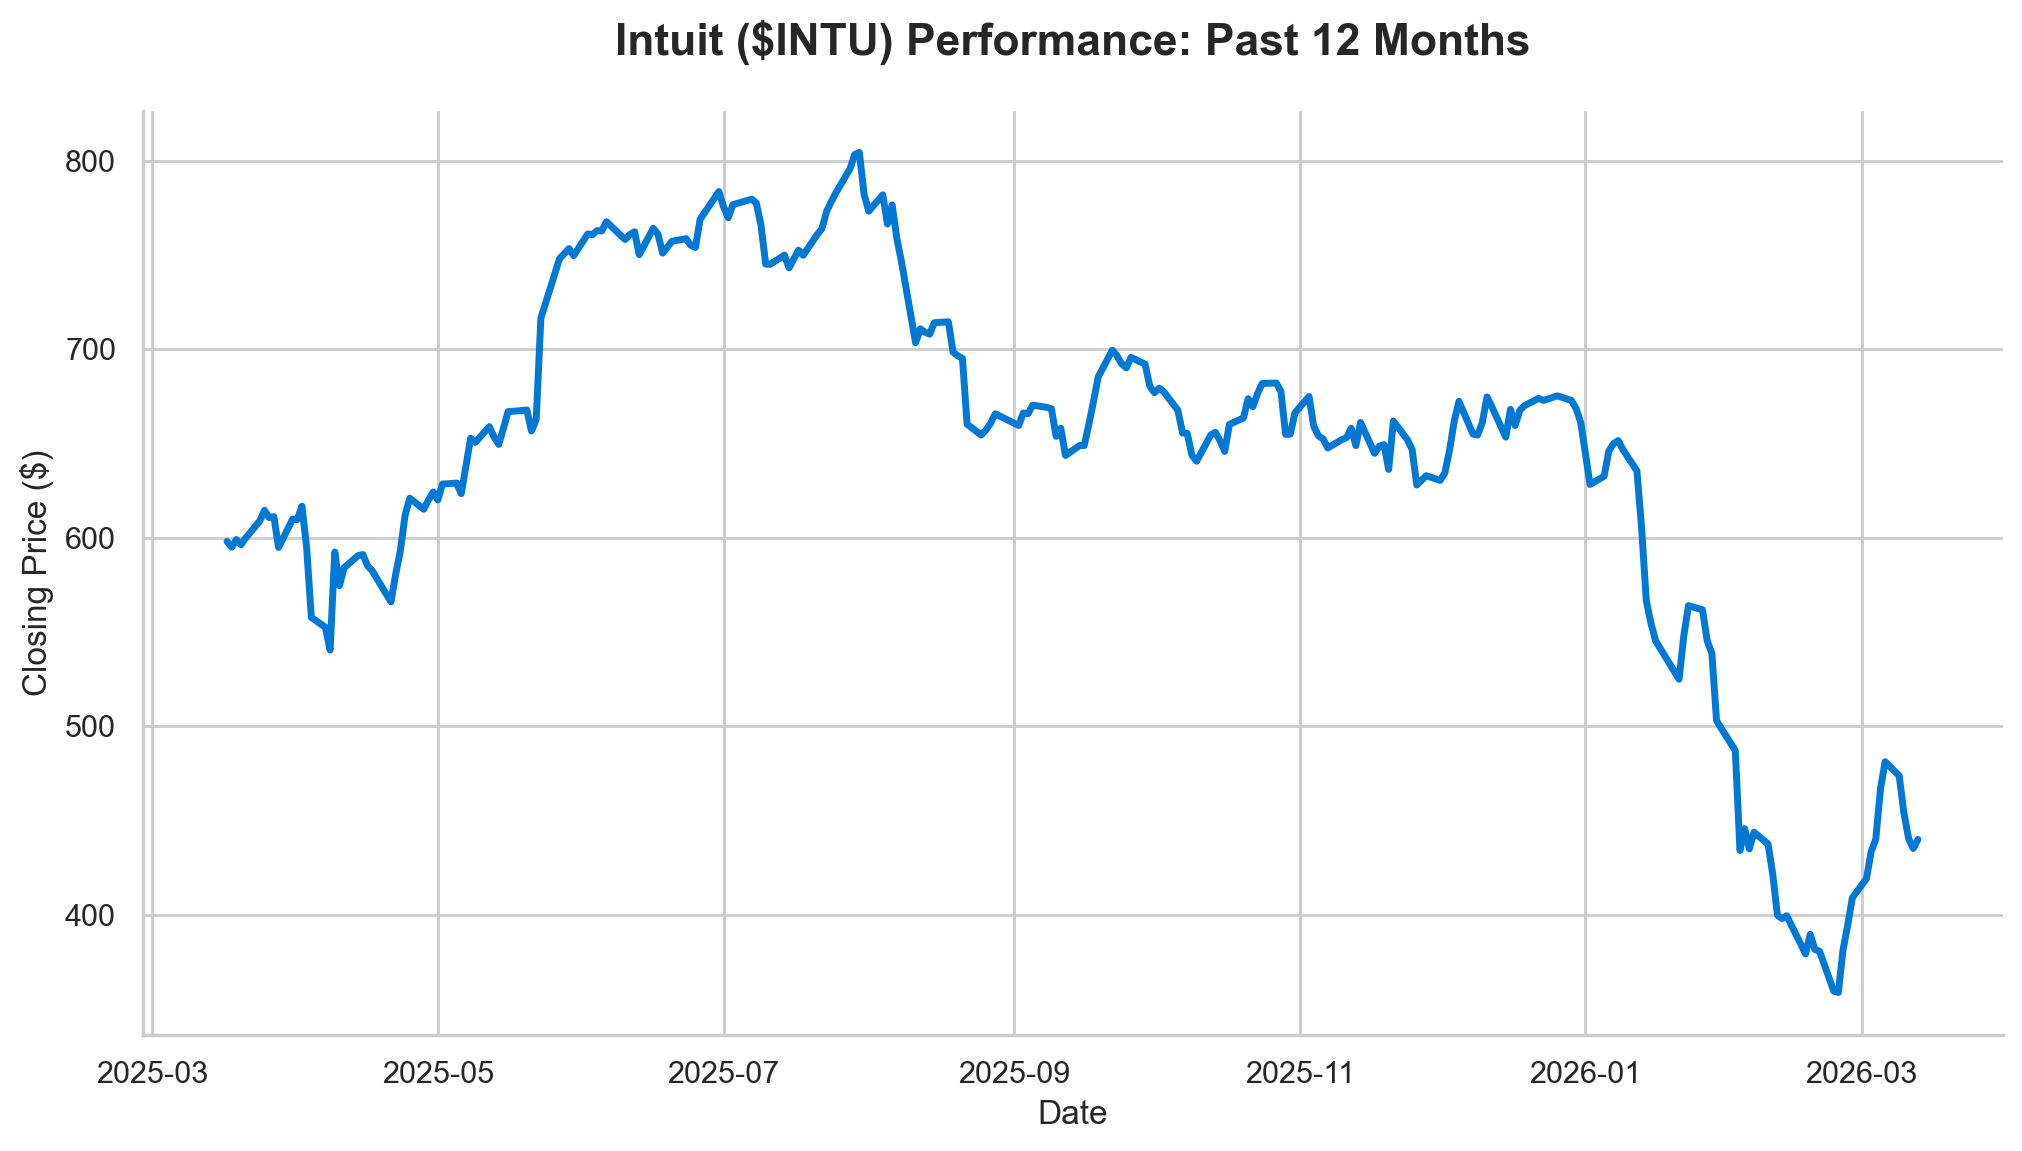

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. High-resolution setting (makes it look crisp on Mac)
%config InlineBackend.figure_format = 'retina'

# 2. Setup the "Prettier" look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. The Fix: We use .flatten() to make the data 1-dimensional
sns.lineplot(data=data, x=data.index, y=data['Close'].values.flatten(), color='#0078D4', linewidth=2.5)

# 4. Add the labels
plt.title("Intuit ($INTU) Performance: Past 12 Months", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price ($)", fontsize=12)

# 5. Remove the extra borders (Despine)
sns.despine()

plt.show()